# Come si stanno evolvendo le competenze più richieste per gli analisti di dati? 
Metodologia 
1. Aggregare il numero di competenze mensilmente 
2. Ri-analizzare in base alla percentuale del totale dei posti di lavoro 
3. Rappresentare graficamente la domanda mensile di competenze

In [57]:
# Importare le librerie necessarie
import ast
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from datasets import load_dataset
from typing import cast

# Caricare il dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = cast(pd.DataFrame, dataset['train'].to_pandas())

# Pulire i dati
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

In [54]:
df_DA_US = df[(df['job_title']== 'Data Analyst') & (df['job_country'] == 'United States')]
df_DA_US['job_posted_month_num'] = df_DA_US['job_posted_date'].dt.month
df_DA_US_exploded = df_DA_US.explode('job_skills')
df_DA_US_pivot = df_DA_US_exploded.pivot_table(index='job_posted_month_num', columns='job_skills', aggfunc='size', fill_value=0)
df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()
df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values(ascending=False).index] # type: ignore
df_DA_US_pivot = df_DA_US_pivot.drop('Total')
df_DA_US_pivot

job_skills,sql,excel,tableau,python,power bi,sas,r,word,powerpoint,oracle,...,flutter,tidyr,theano,elixir,electron,chainer,symphony,svelte,sqlserver,next.js
job_posted_month_num,,,,,,,,,,,,,,,,,,,,,
1,1138,781,646,529,326,394,338,169,176,164,...,0,0,0,0,0,0,0,0,0,0
2,782,544,408,378,302,270,233,128,130,99,...,0,0,0,0,0,0,0,0,0,0
3,802,580,463,400,277,300,241,142,127,107,...,0,0,0,0,0,0,0,0,0,0
4,845,577,462,421,292,258,238,143,133,122,...,1,0,0,0,0,0,0,0,0,0
5,706,490,367,336,251,206,219,92,119,98,...,0,0,0,0,0,0,0,0,0,0
6,742,491,395,396,272,202,252,126,116,99,...,0,0,0,0,1,0,0,0,0,0
7,560,431,296,292,190,182,188,101,101,62,...,0,0,0,0,0,0,0,0,1,1
8,784,641,480,460,292,272,321,112,133,98,...,0,0,0,0,0,0,0,0,0,0
9,485,336,277,253,183,150,157,65,53,67,...,0,0,0,0,0,0,1,0,0,0


In [55]:
DA_totals = df_DA_US.groupby('job_posted_month_num').size() # numero totale di posti di lavoro per mese
df_DA_US_perc = df_DA_US_pivot.div(DA_totals, axis=0) * 100 # calcolare la percentuale di ogni competenza rispetto al totale dei posti di lavoro per mese
df_DA_US_perc = df_DA_US_perc.reset_index()
df_DA_US_perc['job_posted_month'] = df_DA_US_perc['job_posted_month_num'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_US_perc = df_DA_US_perc.set_index('job_posted_month')
df_DA_US_perc = df_DA_US_perc.drop('job_posted_month_num', axis=1)
df_DA_US_perc

job_skills,sql,excel,tableau,python,power bi,sas,r,word,powerpoint,oracle,...,flutter,tidyr,theano,elixir,electron,chainer,symphony,svelte,sqlserver,next.js
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,62.665198,43.006608,35.572687,29.129956,17.951542,21.696035,18.612335,9.306167,9.691630,9.030837,...,0.000000,0.0000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,60.903427,42.367601,31.775701,29.439252,23.520249,21.028037,18.146417,9.968847,10.124611,7.710280,...,0.000000,0.0000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,58.883994,42.584435,33.994126,29.368576,20.337739,22.026432,17.694567,10.425844,9.324523,7.856094,...,0.000000,0.0000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,61.723886,42.147553,33.747261,30.752374,21.329438,18.845873,17.384953,10.445581,9.715121,8.911614,...,0.073046,0.0000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
May,61.072664,42.387543,31.747405,29.065744,21.712803,17.820069,18.944637,7.958478,10.294118,8.477509,...,0.000000,0.0000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,61.474731,40.679370,32.725766,32.808616,22.535211,16.735708,20.878210,10.439105,9.610605,8.202154,...,0.000000,0.0000,0.000000,0.000000,0.08285,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,58.638743,45.130890,30.994764,30.575916,19.895288,19.057592,19.685864,10.575916,10.575916,6.492147,...,0.000000,0.0000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.104712,0.104712
Aug,55.445545,45.332390,33.946252,32.531825,20.650636,19.236209,22.701556,7.920792,9.405941,6.930693,...,0.000000,0.0000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,56.658879,39.252336,32.359813,29.556075,21.378505,17.523364,18.341121,7.593458,6.191589,7.827103,...,0.000000,0.0000,0.000000,0.000000,0.00000,0.000000,0.116822,0.000000,0.000000,0.000000


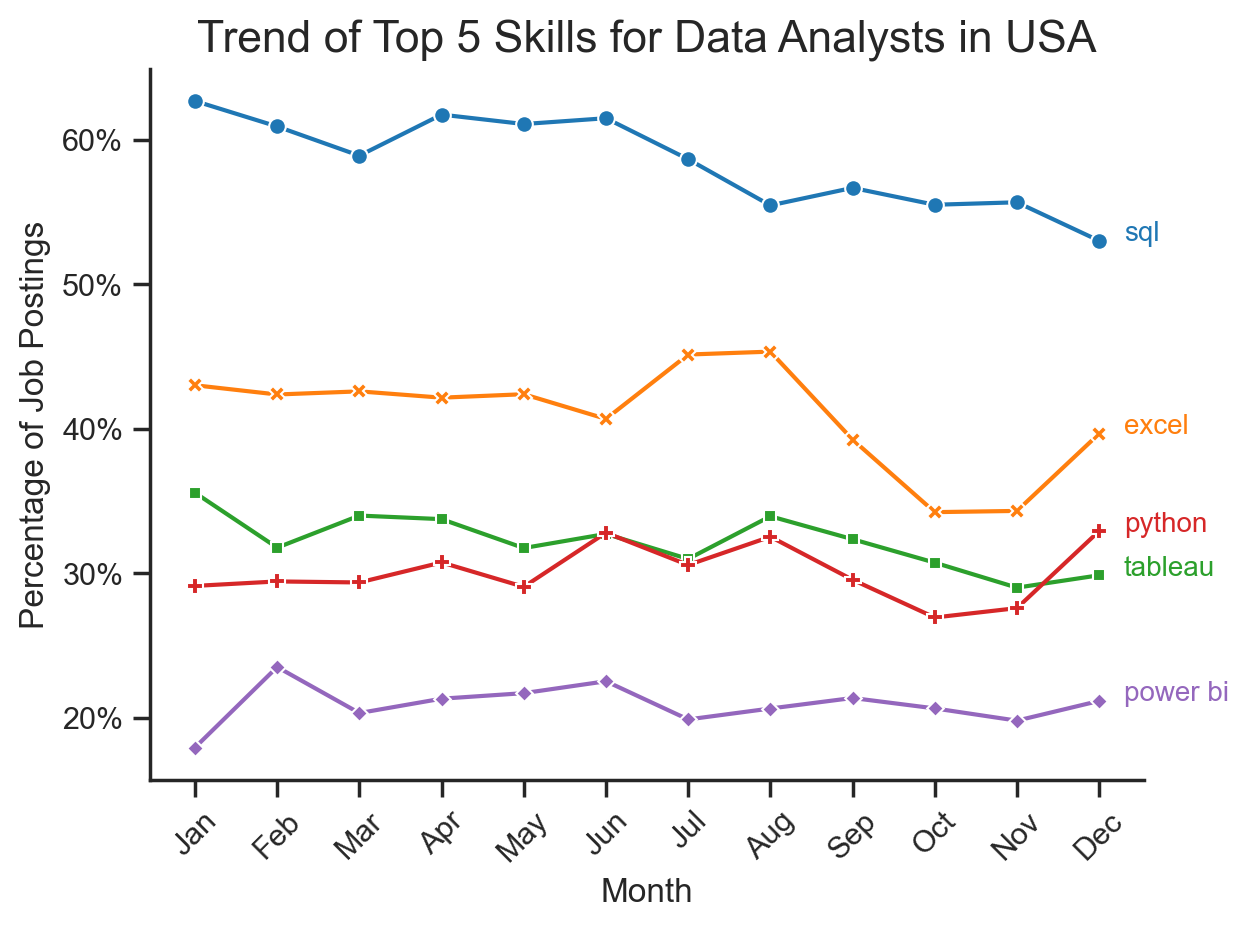

In [60]:
%config InlineBackend.figure_format = 'retina'
df_plot = df_DA_US_perc.iloc[:, :5]
sns.lineplot(data=df_plot, markers=True, palette='tab10', dashes=False)
sns.set_theme(style='ticks')
sns.despine() # rimuove le spine per un look più pulito
plt.title('Trend of Top 5 Skills for Data Analysts in USA', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Percentage of Job Postings', fontsize=12)
for i in range(5):
    plt.text(11.3, df_plot.iloc[-1, i], df_plot.columns[i], color=sns.color_palette('tab10')[i], fontsize=10)
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))
plt.legend().remove()
plt.xticks(rotation=45)
plt.tight_layout()
# per salvarlo in svg in locale
plt.savefig('images/skills_trend_top5.svg', format='svg')